In [2]:
import numpy as np
import matplotlib.pyplot as plt

from qutip import *


0.0
5.025125628140704
10.050251256281408
15.075376884422113
20.100502512562816
25.12562814070352
30.150753768844226
35.175879396984925
40.20100502512563
45.22613065326634
50.25125628140704
55.276381909547744
60.30150753768845
65.32663316582915
70.35175879396985
75.37688442211056
80.40201005025126
85.42713567839196
90.45226130653268
95.47738693467338
100.50251256281408
105.52763819095479
110.55276381909549
115.57788944723619
120.6030150753769
125.6281407035176
130.6532663316583
135.678391959799
140.7035175879397
145.72864321608043
150.75376884422113
155.77889447236183
160.80402010050253
165.82914572864323
170.85427135678393
175.87939698492463
180.90452261306535
185.92964824120605
190.95477386934675
195.97989949748745
201.00502512562815
206.03015075376885
211.05527638190958
216.08040201005028
221.10552763819098
226.13065326633168
231.15577889447238
236.18090452261308
241.2060301507538
246.2311557788945
251.2562814070352
256.2814070351759
261.3065326633166
266.3316582914573
271.3567839195

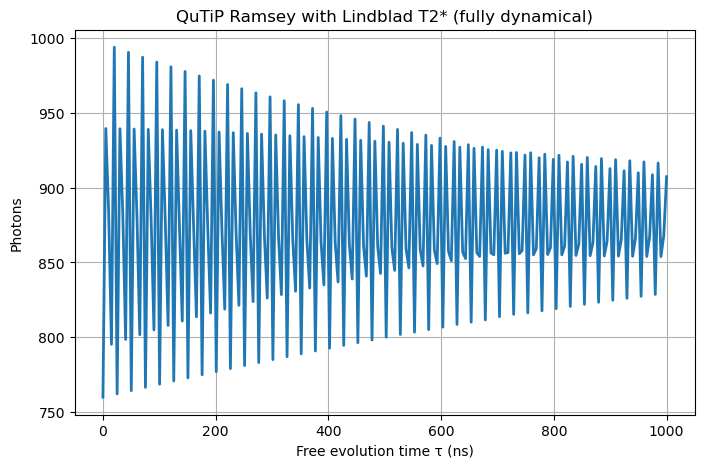

In [6]:
g0 = basis(2, 0)
g1 = basis(2, 1)

psi0 = g0

sx = sigmax()
sy = sigmay()
sz = sigmaz()

P0 = g0 * g0.dag()


Omega = 10.0      # MHz (Rabi frequency)
Delta = 2.0       # MHz (detuning)

T2_star = 2000    # ns (measured Ramsey coherence time)

# QuTiP is unitless, so we keep everything in MHz + ns convention

gamma_phi = 1.0 / T2_star

taus = np.linspace(0, 1000, 200)

# fluorescence model
N_bright = 1000
N_dark = 750



c_ops = [
    np.sqrt(gamma_phi) * sz
]

H_free = 0.5 * Delta * sz
H_drive = 0.5 * Omega * sx


def microwave_coeff(t, args):
    """
    Controls when microwave is ON.

    Sequence:
    - first π/2 pulse
    - free evolution
    - second π/2 pulse
    """

    t1 = args['t1']  # duration of π/2 pulse
    t2 = args['t2']  # end of free evolution

    # First π/2 pulse
    if 0 <= t < t1:
        return 1.0

    # Free evolution (no microwave)
    elif t1 <= t < t1 + t2:
        return 0.0

    # Second π/2 pulse
    elif t1 + t2 <= t < 2*t1 + t2:
        return 1.0

    else:
        return 0.0


# ============================================================
# 6. RAMSEY SIMULATION LOOP
# ============================================================

signal = []

for tau in taus:
    print(tau)
    t_pi2 = np.pi / (2 * Omega)

    # total sequence time
    t_total = 2*t_pi2 + tau

    tlist = np.linspace(0, t_total, 400)

    # Hamiltonian:
    #
    # H = H_free + microwave(t)*H_drive
    #
    H = [
        H_free,
        [H_drive, microwave_coeff]
    ]

    args = {
        't1': t_pi2,
        't2': tau
    }


    result = mesolve(
        H,
        psi0,
        tlist,
        c_ops,
        [P0],
        args=args
    )

    # final bright-state probability
    P0_final = result.expect[0][-1]

    # convert to fluorescence
    photons = (
        N_bright * P0_final
        + N_dark * (1 - P0_final)
    )

    signal.append(photons)

# ============================================================
# 7. PLOT RESULT
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(taus, signal, linewidth=2)

plt.xlabel("Free evolution time τ (ns)")
plt.ylabel("Photons")

plt.title("QuTiP Ramsey with Lindblad T2* (fully dynamical)")

plt.grid(True)
plt.show()